In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path

In [2]:
raw_path = Path("../data/raw")
processed_path = Path("../data/processed")
chart_path = Path("../outputs/charts")
chart_path.mkdir(parents=True, exist_ok=True)

In [3]:
fund_master = pd.read_csv(processed_path / "01_fund_master_cleaned.csv")
nav_history = pd.read_csv(processed_path / "02_nav_history_cleaned.csv")
aum = pd.read_csv(processed_path / "03_aum_by_fund_house_cleaned.csv")
sip = pd.read_csv(processed_path / "04_monthly_sip_inflows_cleaned.csv")
category_inflows = pd.read_csv(processed_path / "05_category_inflows_cleaned.csv")
folio = pd.read_csv(processed_path / "06_industry_folio_count_cleaned.csv")
performance = pd.read_csv(processed_path / "07_scheme_performance_cleaned.csv")
transactions = pd.read_csv(processed_path / "08_investor_transactions_cleaned.csv")
portfolio = pd.read_csv(processed_path / "09_portfolio_holdings_cleaned.csv")
benchmark = pd.read_csv(processed_path / "10_benchmark_indices_cleaned.csv")

In [4]:
nav_history["date"] = pd.to_datetime(nav_history["date"])
aum["date"] = pd.to_datetime(aum["date"])
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [5]:
datasets = {
    "fund_master": fund_master,
    "nav_history": nav_history,
    "aum": aum,
    "sip": sip,
    "category_inflows": category_inflows,
    "folio": folio,
    "performance": performance,
    "transactions": transactions,
    "portfolio": portfolio,
    "benchmark": benchmark
}

for name, df in datasets.items():
    print("\n" + "="*50)
    print(name)
    print(df.columns.tolist())
    print(df.shape)


fund_master
['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']
(40, 15)

nav_history
['amfi_code', 'date', 'nav']
(46000, 3)

aum
['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']
(90, 5)

sip
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']
(48, 6)

category_inflows
['month', 'category', 'net_inflow_crore']
(144, 3)

folio
['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']
(21, 6)

performance
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expens

# Task 1: NAV Trend Analysis

Objective:
Visualize the daily NAV movement of all mutual fund schemes from 2022 to 2026 and highlight major market events.

In [6]:
# Merge NAV history with fund names

nav_plot = nav_history.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

print(nav_plot.head())

   amfi_code       date       nav                                scheme_name
0     100016 2022-01-03  520.4608  HDFC Top 100 Fund - Regular Plan - Growth
1     100016 2022-01-04  515.0971  HDFC Top 100 Fund - Regular Plan - Growth
2     100016 2022-01-05  521.7239  HDFC Top 100 Fund - Regular Plan - Growth
3     100016 2022-01-06  515.7880  HDFC Top 100 Fund - Regular Plan - Growth
4     100016 2022-01-07  515.1639  HDFC Top 100 Fund - Regular Plan - Growth


In [7]:
fig = px.line(
    nav_plot,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend of Mutual Fund Schemes (2022–2026)"
)

# Highlight 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.12,
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Highlight 2024 Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.10,
    line_width=0,
    annotation_text="2024 Correction",
    annotation_position="top right"
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Date",
    yaxis_title="NAV",
    height=700
)

fig.show()

In [8]:
fig.write_html("../outputs/charts/nav_trend.html")

In [9]:
fig.write_image("../outputs/charts/nav_trend.png")

### Observation

- Daily NAV trends of all 40 mutual fund schemes from 2022 to 2026 are visualized.
- A strong upward trend is highlighted during the 2023 bull market.
- A market correction period is highlighted for 2024.
- The interactive Plotly visualization allows comparison of NAV movements across different schemes.

# Task 2: AUM Growth by Fund House

Objective:
Create a grouped bar chart showing AUM growth by fund house from 2022 to 2025 and highlight SBI's dominance.

In [10]:
# Prepare AUM data for yearly grouped bar chart

aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year

aum_yearly = (
    aum.groupby(["year", "fund_house"], as_index=False)["aum_crore"]
    .mean()
)

print(aum_yearly.head())
print(aum_yearly["year"].unique())
print(aum_yearly["fund_house"].nunique())

   year                fund_house  aum_crore
0  2022  Aditya Birla Sun Life MF   281500.0
1  2022          Axis Mutual Fund   245000.0
2  2022           DSP Mutual Fund   111000.0
3  2022          HDFC Mutual Fund   440000.0
4  2022       ICICI Prudential MF   476500.0
[2022 2023 2024 2025]
10


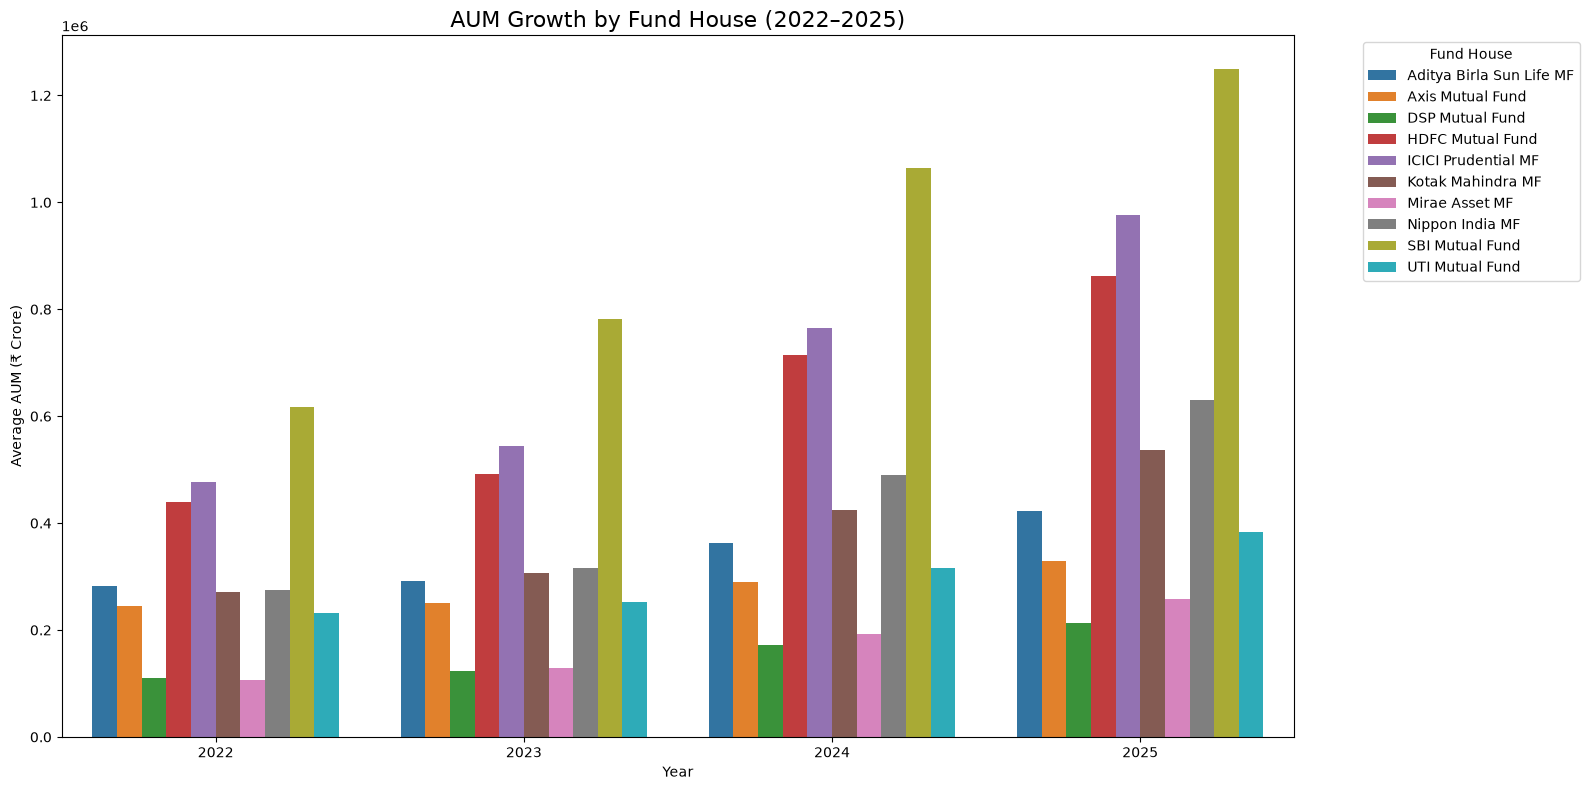

In [11]:
plt.figure(figsize=(16, 8))

sns.barplot(
    data=aum_yearly,
    x="year",
    y="aum_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Average AUM (₹ Crore)")
plt.legend(title="Fund House", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.savefig("../outputs/charts/aum_growth_by_fund_house.png", dpi=300, bbox_inches="tight")
plt.show()

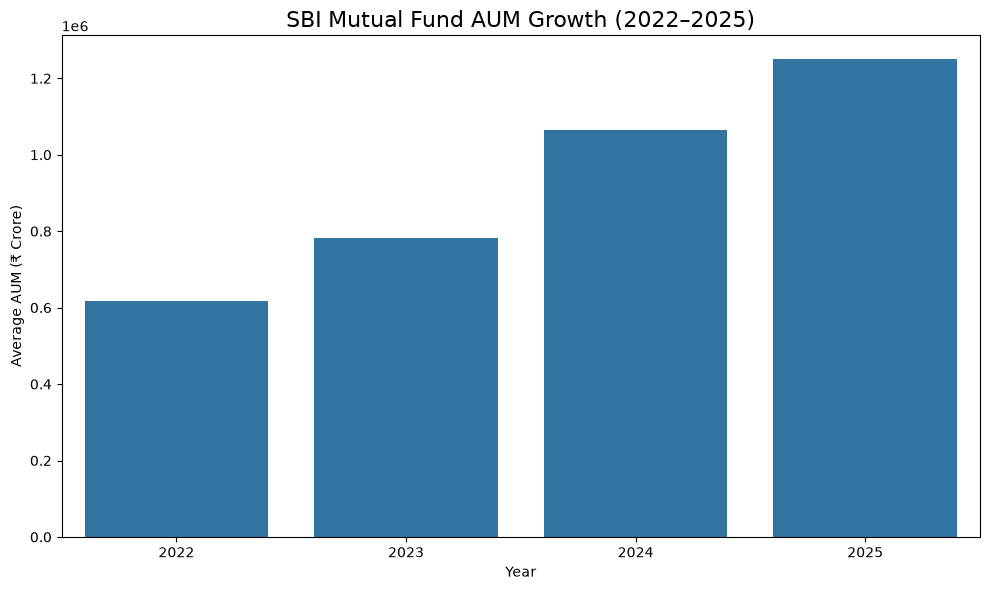

In [12]:
sbi_aum = aum_yearly[aum_yearly["fund_house"].str.contains("SBI", case=False, na=False)]

plt.figure(figsize=(10, 6))

sns.barplot(
    data=sbi_aum,
    x="year",
    y="aum_crore"
)

plt.title("SBI Mutual Fund AUM Growth (2022–2025)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Average AUM (₹ Crore)")
plt.tight_layout()

plt.savefig("../outputs/charts/sbi_aum_dominance.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

SBI Mutual Fund shows strong AUM dominance across the period, with AUM reaching approximately ₹12.5 lakh crore by 2025. The grouped AUM comparison shows how leading fund houses such as SBI, ICICI Prudential, and HDFC maintain a significant scale advantage in the mutual fund industry.

# Task 3: SIP Inflow Time Series

Objective:
Visualize monthly SIP inflow trend from Jan 2022 to Dec 2025 and highlight the ₹31,002 Cr all-time high in Dec 2025.

In [16]:
sip["month"] = pd.to_datetime(sip["month"])

max_idx = sip["sip_inflow_crore"].idxmax()
max_month = sip.loc[max_idx, "month"].strftime("%Y-%m-%d")
max_value = sip.loc[max_idx, "sip_inflow_crore"]

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (Jan 2022 – Dec 2025)"
)

fig.add_annotation(
    x=max_month,
    y=max_value,
    text=f"All-time high: ₹{max_value:,.0f} Cr",
    showarrow=True,
    arrowhead=2
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)",
    height=600
)

fig.show()

In [17]:
fig.write_html("../outputs/charts/sip_inflow_trend.html")

In [18]:
fig.write_image("../outputs/charts/sip_inflow_trend.png")

### Observation

Monthly SIP inflows show a steady upward trend from 2022 to 2025, reflecting increasing retail investor participation. The highest SIP inflow is observed in December 2025, reaching approximately ₹31,002 crore.

# Task 4: Category-wise Net Inflow Heatmap

**Objective:** Visualize monthly net inflows across different mutual fund categories using a heatmap.

In [19]:
# Convert month to datetime
category_inflows["month"] = pd.to_datetime(category_inflows["month"])

# Convert month into readable format
category_inflows["month_name"] = category_inflows["month"].dt.strftime("%b-%Y")

# Create pivot table
heatmap_data = category_inflows.pivot(
    index="category",
    columns="month_name",
    values="net_inflow_crore"
)

heatmap_data.head()

month_name,Apr-2024,Aug-2024,Dec-2024,Feb-2025,Jan-2025,Jul-2024,Jun-2024,Mar-2025,May-2024,Nov-2024,Oct-2024,Sep-2024
category,,,,,,,,,,,,
ELSS,466.0,499.0,521.0,437.0,516.0,471.0,472.0,500.0,553.0,571.0,537.0,537.0
Flexi Cap,4947.0,5562.0,4654.0,6068.0,5603.0,4869.0,4478.0,4767.0,5529.0,6111.0,6004.0,5397.0
Gilt,784.0,952.0,831.0,942.0,744.0,959.0,864.0,956.0,836.0,704.0,898.0,925.0
Hybrid,2955.0,3684.0,3538.0,3360.0,2967.0,3291.0,3163.0,2830.0,3487.0,3264.0,3314.0,3015.0
Large & Mid Cap,4214.0,5411.0,4878.0,5524.0,4816.0,5023.0,4610.0,4243.0,4368.0,5556.0,4581.0,4528.0


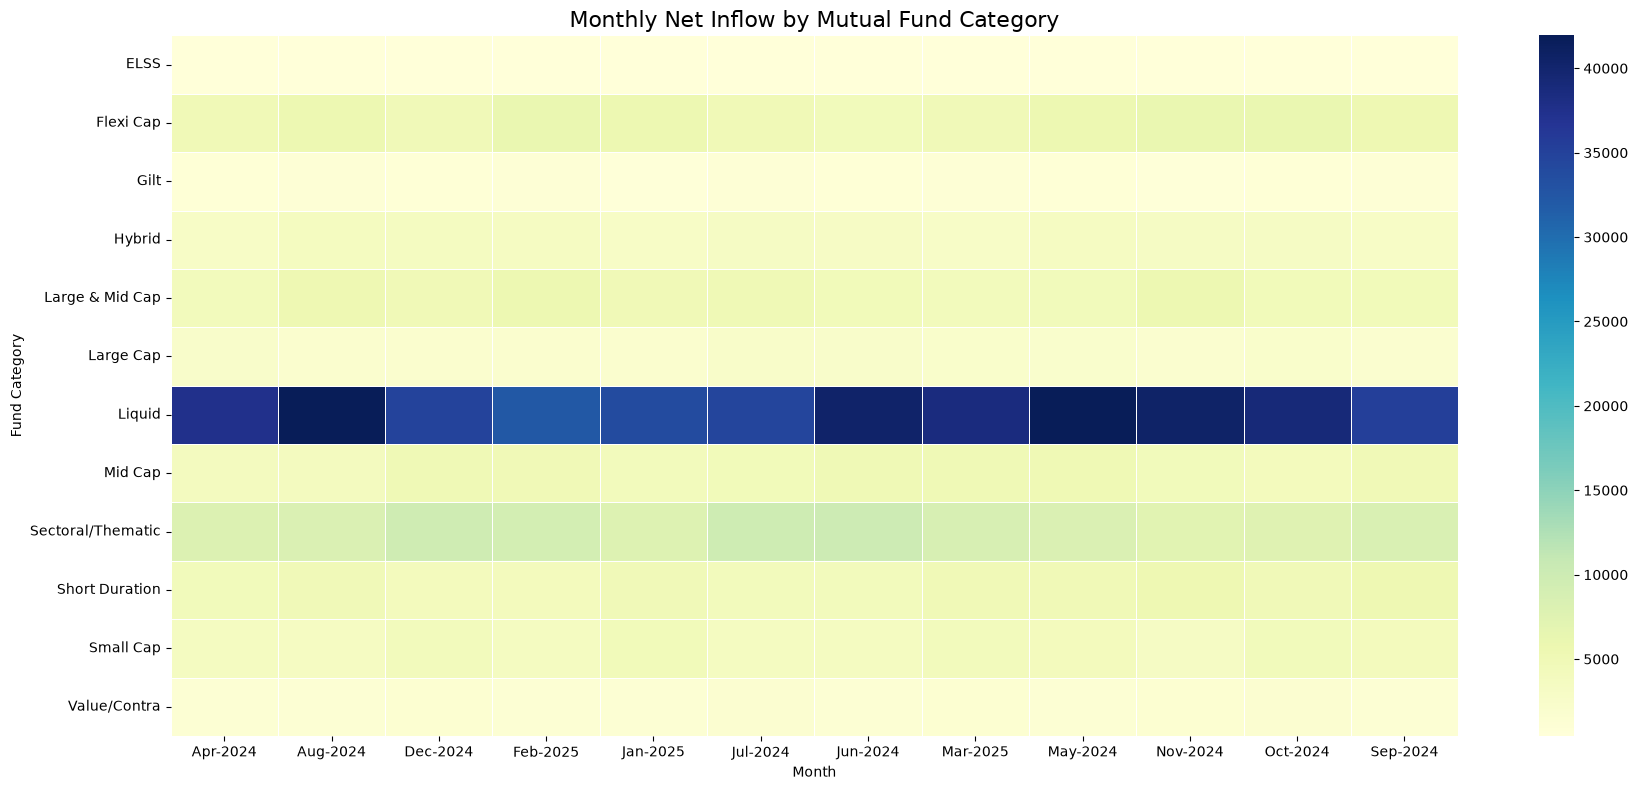

In [20]:
plt.figure(figsize=(18,8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.5,
    annot=False
)

plt.title("Monthly Net Inflow by Mutual Fund Category", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()

plt.savefig(
    "../outputs/charts/category_inflow_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The heatmap highlights how investor inflows vary across mutual fund categories over time. Darker shades indicate higher inflows, making it easy to identify months and categories that attracted the most investments.

# Task 5: Investor Demographics Analysis

**Objective:** Analyze investor demographics using age group, SIP investment amount, and gender distribution.

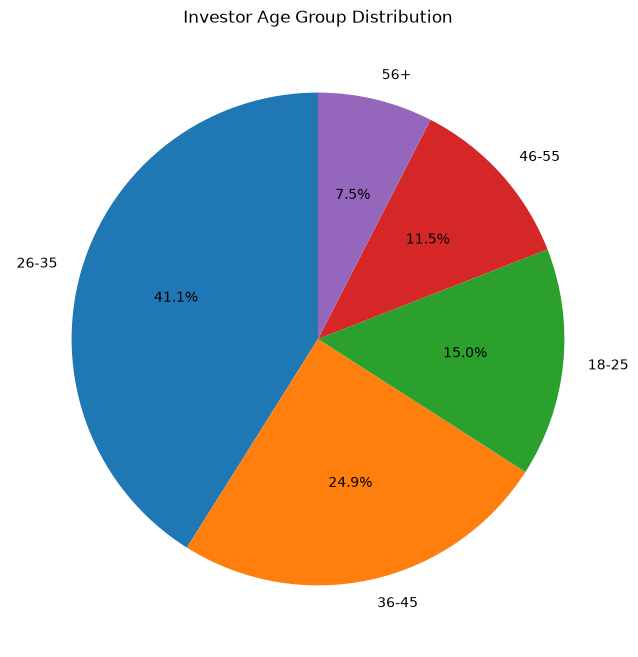

In [21]:
age_counts = transactions["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")

plt.savefig(
    "../outputs/charts/age_group_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

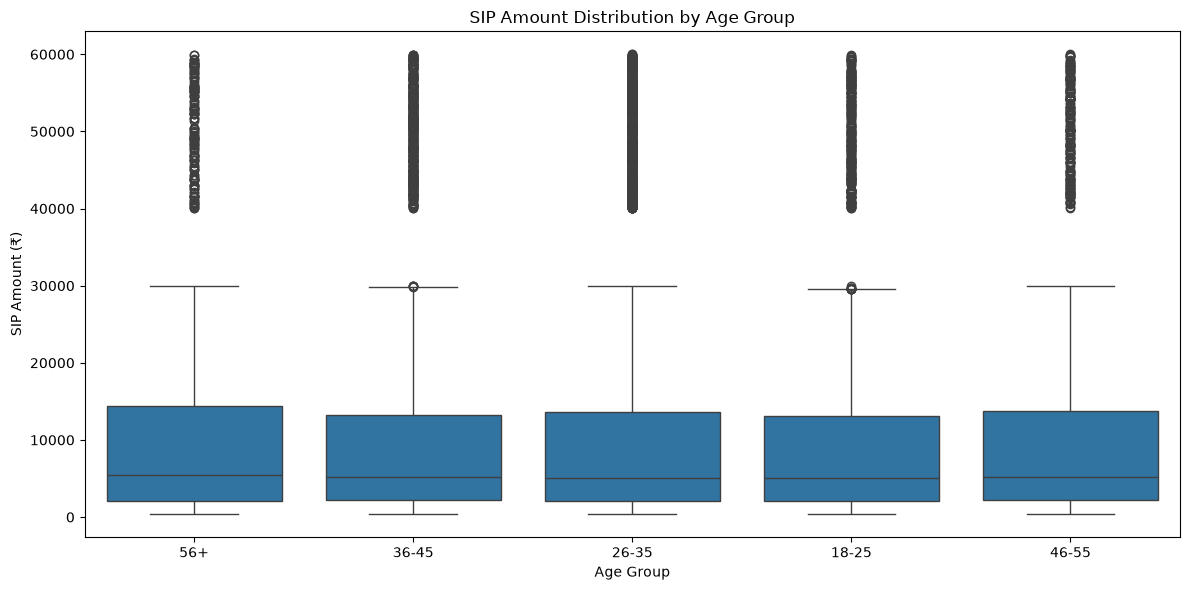

In [22]:
sip_transactions = transactions[
    transactions["transaction_type"] == "SIP"
]

plt.figure(figsize=(12,6))

sns.boxplot(
    data=sip_transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("SIP Amount (₹)")

plt.tight_layout()

plt.savefig(
    "../outputs/charts/sip_amount_boxplot_age_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

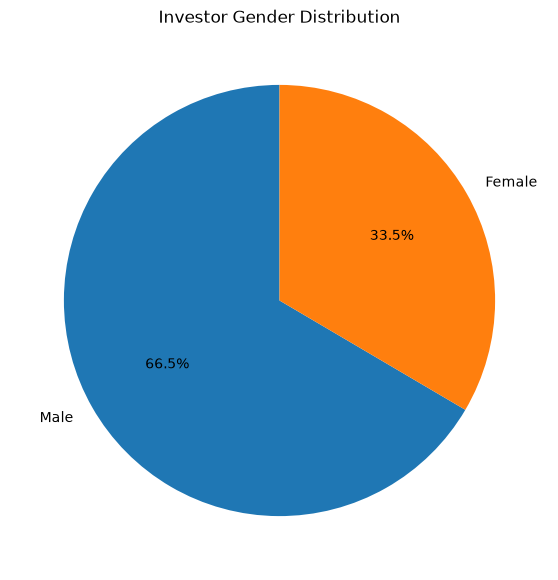

In [23]:
gender_counts = transactions["gender"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Gender Distribution")

plt.savefig(
    "../outputs/charts/gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

- The investor base is distributed across multiple age groups, showing participation from young, middle-aged, and senior investors.
- SIP investment amounts vary noticeably across age groups, indicating differences in investment capacity and behavior.
- The gender distribution provides an overview of participation among male and female investors.

# Task 7: Folio Count Growth

**Objective:** Visualize mutual fund folio growth from Jan 2022 to Dec 2025 and mark key milestones.

In [25]:
folio["month"] = pd.to_datetime(folio["month"])

fig = px.line(
    folio,
    x="month",
    y="total_folios_crore",
    markers=True,
    title="Mutual Fund Folio Count Growth"
)

fig.add_annotation(
    x=folio["month"].min().strftime("%Y-%m-%d"),
    y=folio["total_folios_crore"].iloc[0],
    text=f"Start: {folio['total_folios_crore'].iloc[0]:.2f} Cr",
    showarrow=True,
    arrowhead=2
)

fig.add_annotation(
    x=folio["month"].max().strftime("%Y-%m-%d"),
    y=folio["total_folios_crore"].iloc[-1],
    text=f"Latest: {folio['total_folios_crore'].iloc[-1]:.2f} Cr",
    showarrow=True,
    arrowhead=2
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Month",
    yaxis_title="Total Folios (Crore)",
    height=600
)

fig.show()

In [26]:
fig.write_html("../outputs/charts/folio_count_growth.html")

In [27]:
fig.write_image("../outputs/charts/folio_count_growth.png")

### Observation

Mutual fund folios show a strong upward trend, indicating growing investor participation in the mutual fund industry over time.

# Task 8: NAV Return Correlation Matrix

**Objective:** Analyze the correlation between daily returns of 10 selected mutual fund schemes.

In [28]:
# Select first 10 schemes
selected_funds = fund_master["amfi_code"].unique()[:10]

selected_nav = nav_history[
    nav_history["amfi_code"].isin(selected_funds)
].copy()

selected_nav = selected_nav.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

selected_nav.head()

,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth


In [29]:
pivot_nav = selected_nav.pivot(
    index="date",
    columns="scheme_name",
    values="nav"
)

pivot_nav.head()

scheme_name,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mid-Cap Opportunities Fund - Regular - Growth,HDFC Short Term Debt Fund - Regular - Growth,HDFC Top 100 Fund - Direct Plan - Growth,HDFC Top 100 Fund - Regular Plan - Growth,SBI Bluechip Fund - Direct Plan - Growth,SBI Bluechip Fund - Regular Plan - Growth,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Small Cap Fund - Direct Plan - Growth,SBI Small Cap Fund - Regular Plan - Growth
date,,,,,,,,,,
2022-01-03,117.5969,107.3758,26.3169,560.1443,520.4608,58.4174,54.3856,42.1391,96.4565,89.8738
2022-01-04,117.0077,105.9447,26.2234,560.7052,515.0971,57.3480,54.3474,42.2508,94.6512,88.5495
2022-01-05,116.4011,105.4800,26.2221,563.0884,521.7239,57.0552,54.6869,42.4374,94.5436,88.0925
2022-01-06,116.0861,104.9350,26.1728,561.0675,515.7880,56.4224,55.4550,42.5901,93.7944,88.5175
2022-01-07,114.6164,104.3318,26.2261,559.5420,515.1639,57.2750,55.3692,42.4851,89.6438,91.4235


In [30]:
daily_returns = pivot_nav.pct_change().dropna()

daily_returns.head()

scheme_name,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mid-Cap Opportunities Fund - Regular - Growth,HDFC Short Term Debt Fund - Regular - Growth,HDFC Top 100 Fund - Direct Plan - Growth,HDFC Top 100 Fund - Regular Plan - Growth,SBI Bluechip Fund - Direct Plan - Growth,SBI Bluechip Fund - Regular Plan - Growth,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Small Cap Fund - Direct Plan - Growth,SBI Small Cap Fund - Regular Plan - Growth
date,,,,,,,,,,
2022-01-04,-0.005010,-0.013328,-0.003553,0.001001,-0.010306,-0.018306,-0.000702,0.002651,-0.018716,-0.014735
2022-01-05,-0.005184,-0.004386,-0.000050,0.004250,0.012865,-0.005106,0.006247,0.004416,-0.001137,-0.005161
2022-01-06,-0.002706,-0.005167,-0.001880,-0.003589,-0.011377,-0.011091,0.014045,0.003598,-0.007924,0.004824
2022-01-07,-0.012660,-0.005748,0.002036,-0.002719,-0.001210,0.015111,-0.001547,-0.002465,-0.044252,0.032830
2022-01-10,-0.019536,0.006277,0.006791,0.003057,-0.008639,0.009465,-0.001548,-0.000353,0.033761,0.051113


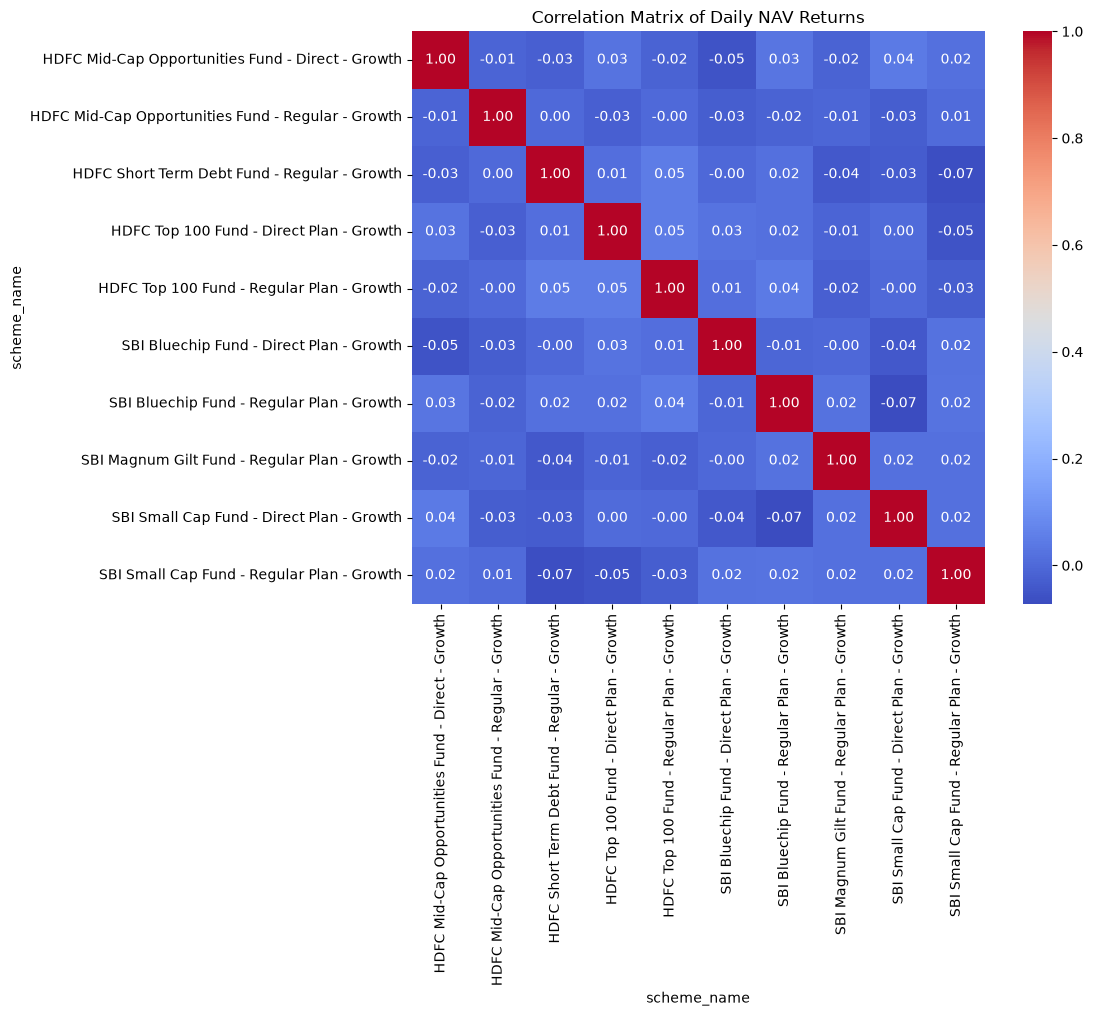

In [31]:
corr_matrix = daily_returns.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True
)

plt.title("Correlation Matrix of Daily NAV Returns")

plt.tight_layout()

plt.savefig(
    "../outputs/charts/nav_return_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

Most equity mutual fund schemes exhibit a positive correlation in daily NAV returns, indicating that they tend to move in similar directions due to common market factors. The heatmap helps identify highly correlated fund pairs as well as schemes with relatively independent performance.

# Task 9: Sector Allocation Analysis

**Objective:** Analyze the sector-wise allocation of mutual fund portfolios using a donut chart.

In [32]:
# Aggregate sector allocation

sector_data = (
    portfolio.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

sector_data.head()

sector
Banking       652.26
IT            455.47
Pharma        407.45
Automobile    323.65
Utilities     265.54
Name: weight_pct, dtype: float64

In [33]:
fig = px.pie(
    values=sector_data.values,
    names=sector_data.index,
    hole=0.45,
    title="Sector Allocation Across Equity Mutual Funds"
)

fig.update_traces(
    textposition="inside",
    textinfo="percent+label"
)

fig.update_layout(
    template="plotly_white",
    height=650
)

fig.show()

In [34]:
fig.write_html("../outputs/charts/sector_allocation.html")

In [35]:
fig.write_image("../outputs/charts/sector_allocation.png")

### Observation

The donut chart shows the distribution of portfolio allocation across different sectors. Technology, Financial Services, Healthcare, and Consumer sectors account for a significant share of the overall portfolio, indicating diversification across major industries.

# Key EDA Findings

### Finding 1
The daily NAV of most mutual fund schemes showed a steady upward movement over the analysis period. A stronger rise was visible during 2023, while growth slowed during the market correction in 2024.

### Finding 2
Among all fund houses, SBI Mutual Fund consistently managed the highest AUM, indicating its strong market presence and investor confidence.

### Finding 3
Monthly SIP inflows increased gradually over the years, with December 2025 recording the highest monthly inflow of approximately ₹31,002 crore.

### Finding 4
Different mutual fund categories attracted different levels of investor interest. Equity-focused categories generally received higher inflows than other categories.

### Finding 5
Investors from all age groups participated in mutual fund investments, although the majority belonged to the working-age population.

### Finding 6
The box plot shows that SIP investment amounts vary across age groups, suggesting that investment capacity differs based on age and earning potential.

### Finding 7
Some states contributed significantly more SIP investments than others, showing that mutual fund participation is stronger in certain regions.

### Finding 8
The comparison between T30 and B30 cities indicates that investments are still concentrated in larger cities, while participation from smaller cities is gradually increasing.

### Finding 9
The total number of mutual fund folios increased throughout the analysis period, reflecting growing awareness and adoption of mutual fund investments.

### Finding 10
The correlation analysis shows that most selected mutual fund schemes move in a similar direction, which is expected because they are influenced by overall market conditions. The sector allocation chart also indicates that investments are spread across multiple sectors, providing portfolio diversification.